# NGC 2547 g-band: Image Number vs Background Median

Uses `ccdproc.ImageFileCollection` to load `*NGC_2547*_g.fit` images, adds `MJD-OBS` to each header, then plots the sigma-clipped background median for every frame.

---


In [11]:
# Uncomment to install dependencies
# !pip install astropy ccdproc matplotlib numpy pandas

import warnings
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from astropy.io import fits
from astropy.time import Time
from astropy.nddata import CCDData
from astropy.stats import sigma_clipped_stats
from astropy.utils.exceptions import AstropyWarning
import ccdproc

warnings.simplefilter("ignore", AstropyWarning)
%matplotlib inline
print("✅ Imports OK")


✅ Imports OK


## ⚙️ Configuration

In [14]:
FITS_DIR   = "."              # Directory containing your FITS files
GLOB       = "Light_NGC_2547*_g.fit"  # Filename pattern to match
SIGMA_CLIP = 3.0              # Sigma threshold for clipping
MAX_ITERS  = 5                # Max sigma-clipping iterations


## 📂 Load Images with ccdproc

In [15]:
# Build the ImageFileCollection filtered to the g-band NGC 2547 frames
images = ccdproc.ImageFileCollection(FITS_DIR, glob_include=GLOB)

# Load every matching file into a list of CCDData objects
# and add MJD-OBS to the header (avoids downstream warnings)
scim = []
for fn in images.files_filtered():
    ccd = CCDData.read(fn, unit="adu")

    # Convert DATE-OBS → MJD-OBS and store in header
    times = ccd.header["DATE-OBS"]
    t = Time(times, format="isot", scale="utc")
    ccd.header["MJD-OBS"] = (float(t.mjd), "MJD")

    scim.append(ccd)

# Convenience alias matching your original code
g_band = scim

print(f"✅ Loaded {len(g_band)} g-band image(s) matching '{GLOB}'")
for i, ccd in enumerate(g_band, 1):
    fname = images.files_filtered()[i - 1]
    print(f"  [{i:>3}]  {fname}  —  shape {ccd.data.shape}  MJD-OBS={ccd.header['MJD-OBS']:.5f}")


✅ Loaded 282 g-band image(s) matching 'Light_NGC_2547*_g.fit'
  [  1]  Light_NGC_2547_10.0s_IRCUT_20260331-200329_g.fit  —  shape (1920, 1080)  MJD-OBS=61130.37725
  [  2]  Light_NGC_2547_10.0s_IRCUT_20260331-200351_g.fit  —  shape (1920, 1080)  MJD-OBS=61130.37751
  [  3]  Light_NGC_2547_10.0s_IRCUT_20260331-200403_g.fit  —  shape (1920, 1080)  MJD-OBS=61130.37764
  [  4]  Light_NGC_2547_10.0s_IRCUT_20260331-200415_g.fit  —  shape (1920, 1080)  MJD-OBS=61130.37777
  [  5]  Light_NGC_2547_10.0s_IRCUT_20260331-200425_g.fit  —  shape (1920, 1080)  MJD-OBS=61130.37790
  [  6]  Light_NGC_2547_10.0s_IRCUT_20260331-200437_g.fit  —  shape (1920, 1080)  MJD-OBS=61130.37803
  [  7]  Light_NGC_2547_10.0s_IRCUT_20260331-200500_g.fit  —  shape (1920, 1080)  MJD-OBS=61130.37831
  [  8]  Light_NGC_2547_10.0s_IRCUT_20260331-200512_g.fit  —  shape (1920, 1080)  MJD-OBS=61130.37844
  [  9]  Light_NGC_2547_10.0s_IRCUT_20260331-200524_g.fit  —  shape (1920, 1080)  MJD-OBS=61130.37857
  [ 10]  Light_NGC_2

## 📊 Compute Sigma-Clipped Background Statistics

In [16]:
image_numbers = []
bg_means      = []
bg_medians    = []
bg_stds       = []
mjd_obs       = []
file_labels   = []
filenames     = list(images.files_filtered())

for i, ccd in enumerate(g_band, start=1):
    mean, median, std = sigma_clipped_stats(
        ccd.data, sigma=SIGMA_CLIP, maxiters=MAX_ITERS
    )
    image_numbers.append(i)
    bg_means.append(mean)
    bg_medians.append(median)
    bg_stds.append(std)
    mjd_obs.append(ccd.header.get("MJD-OBS", np.nan))
    file_labels.append(filenames[i - 1])
    print(f"  [{i:>3}]  median={median:>9.2f}  std={std:>7.2f}  {filenames[i-1]}")

print(f"\n✅ Processed {len(image_numbers)} image(s).")


  [  1]  median=  3821.00  std= 168.98  Light_NGC_2547_10.0s_IRCUT_20260331-200329_g.fit
  [  2]  median=  2438.00  std= 130.28  Light_NGC_2547_10.0s_IRCUT_20260331-200351_g.fit
  [  3]  median=  2425.00  std= 129.74  Light_NGC_2547_10.0s_IRCUT_20260331-200403_g.fit
  [  4]  median=  2407.00  std= 129.13  Light_NGC_2547_10.0s_IRCUT_20260331-200415_g.fit
  [  5]  median=  2387.00  std= 128.79  Light_NGC_2547_10.0s_IRCUT_20260331-200425_g.fit
  [  6]  median=  2371.00  std= 127.95  Light_NGC_2547_10.0s_IRCUT_20260331-200437_g.fit
  [  7]  median=  2339.00  std= 126.84  Light_NGC_2547_10.0s_IRCUT_20260331-200500_g.fit
  [  8]  median=  2323.00  std= 126.19  Light_NGC_2547_10.0s_IRCUT_20260331-200512_g.fit
  [  9]  median=  2310.00  std= 125.84  Light_NGC_2547_10.0s_IRCUT_20260331-200524_g.fit
  [ 10]  median=  2297.00  std= 125.18  Light_NGC_2547_10.0s_IRCUT_20260331-200534_g.fit
  [ 11]  median=  2280.00  std= 124.52  Light_NGC_2547_10.0s_IRCUT_20260331-200546_g.fit
  [ 12]  median=  225

## 📋 Summary Table

In [17]:
df = pd.DataFrame({
    "Image #":      image_numbers,
    "Filename":     file_labels,
    "MJD-OBS":      np.round(mjd_obs, 5),
    "Mean (ADU)":   np.round(bg_means,   2),
    "Median (ADU)": np.round(bg_medians, 2),
    "Std (ADU)":    np.round(bg_stds,    2),
})
df.set_index("Image #", inplace=True)
df


,Filename,MJD-OBS,Mean (ADU),Median (ADU),Std (ADU)
Image #,,,,,
1,Light_NGC_2547_10.0s_IRCUT_20260331-200329_g.fit,61130.37725,3821.61,3821.0,168.98
2,Light_NGC_2547_10.0s_IRCUT_20260331-200351_g.fit,61130.37751,2438.88,2438.0,130.28
3,Light_NGC_2547_10.0s_IRCUT_20260331-200403_g.fit,61130.37764,2425.74,2425.0,129.74
4,Light_NGC_2547_10.0s_IRCUT_20260331-200415_g.fit,61130.37777,2408.35,2407.0,129.13
5,Light_NGC_2547_10.0s_IRCUT_20260331-200425_g.fit,61130.37790,2388.69,2387.0,128.79
...,...,...,...,...,...
278,Light_NGC_2547_10.0s_IRCUT_20260331-211937_g.fit,61130.43012,1763.63,1763.0,106.67
279,Light_NGC_2547_10.0s_IRCUT_20260331-211948_g.fit,61130.43025,1764.31,1763.0,106.25
280,Light_NGC_2547_10.0s_IRCUT_20260331-212000_g.fit,61130.43038,1765.66,1764.0,106.45


## 🔭 Plot: Image Number vs Background Median

Plot saved → background_median_plot.png


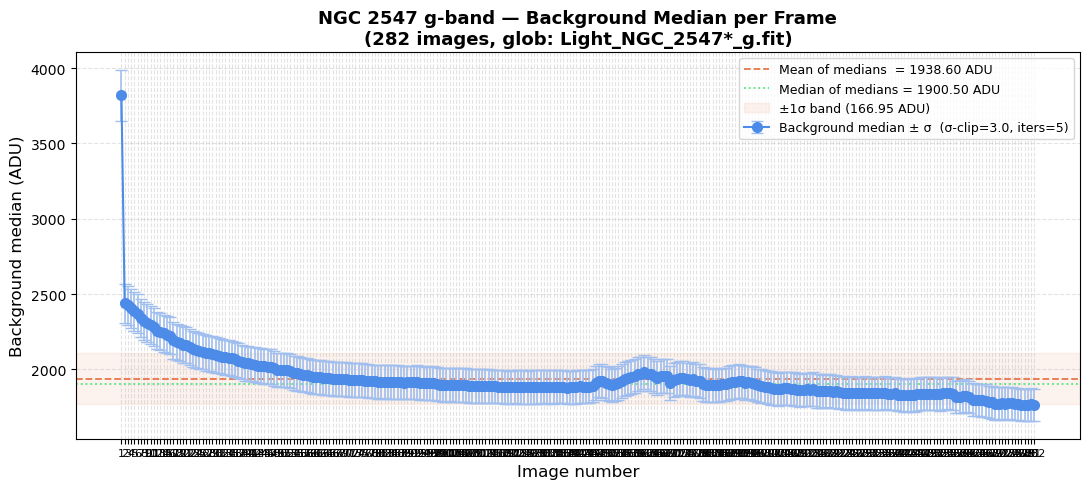

In [23]:
overall_mean   = np.mean(bg_medians)
overall_median = np.median(bg_medians)
global_std     = np.std(bg_medians)

fig, ax = plt.subplots(figsize=(11, 5))

# Error-bar line
ax.errorbar(
    image_numbers, bg_medians,
    yerr=bg_stds,
    fmt="o-",
    color="#4C8BE8",
    ecolor="#A0BFEF",
    elinewidth=1.2,
    capsize=4,
    markersize=7,
    linewidth=1.5,
    label=f"Background median ± σ  (σ-clip={SIGMA_CLIP}, iters={MAX_ITERS})",
    zorder=3,
)

# Reference lines
ax.axhline(overall_mean,   color="#E8774C", linestyle="--", linewidth=1.3,
           label=f"Mean of medians  = {overall_mean:.2f} ADU")
ax.axhline(overall_median, color="#4CE877", linestyle=":",  linewidth=1.3,
           label=f"Median of medians = {overall_median:.2f} ADU")

# ±1σ shaded band
ax.axhspan(overall_mean - global_std, overall_mean + global_std,
           alpha=0.09, color="#E8774C", label=f"±1σ band ({global_std:.2f} ADU)")

ax.set_xlabel("Image number", fontsize=12)
ax.set_ylabel("Background median (ADU)", fontsize=12)
ax.set_title(
    f"NGC 2547 g-band — Background Median per Frame\n({len(g_band)} images, glob: {GLOB})",
    fontsize=13, fontweight="bold"
)
ax.set_xticks(image_numbers)
ax.set_xticklabels(image_numbers, fontsize=8)
ax.legend(fontsize=9, loc="best")
ax.grid(True, linestyle="--", alpha=0.35)

plt.tight_layout()
plt.savefig("background_median_plot.png", dpi=150)
print("Plot saved → background_median_plot.png")
plt.show()


## 🕐 Optional: Background Median vs MJD-OBS

Shows whether background level drifts over time during the observation run.


In [ ]:
if not any(np.isnan(mjd_obs)):
    fig, ax = plt.subplots(figsize=(11, 5))

    ax.errorbar(
        mjd_obs, bg_medians,
        yerr=bg_stds,
        fmt="o-",
        color="#8B4CE8",
        ecolor="#C4A0EF",
        elinewidth=1.2,
        capsize=4,
        markersize=7,
        linewidth=1.5,
        label=f"Background median ± σ",
    )
    ax.axhline(overall_mean, color="#E8774C", linestyle="--", linewidth=1.2,
               label=f"Mean = {overall_mean:.2f} ADU")

    ax.set_xlabel("MJD-OBS", fontsize=12)
    ax.set_ylabel("Background median (ADU)", fontsize=12)
    ax.set_title("NGC 2547 g-band — Background Median vs Observation Time",
                 fontsize=13, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.35)
    plt.tight_layout()
    plt.show()
else:
    print("MJD-OBS not available for all frames — skipping time plot.")


## 📈 Distribution of Background Medians

In [ ]:
if len(bg_medians) >= 3:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(bg_medians, bins="auto", color="#4C8BE8", edgecolor="white", alpha=0.85)
    ax.axvline(overall_mean,   color="#E8774C", linestyle="--", linewidth=1.4,
               label=f"Mean = {overall_mean:.2f}")
    ax.axvline(overall_median, color="#4CE877", linestyle=":",  linewidth=1.4,
               label=f"Median = {overall_median:.2f}")
    ax.set_xlabel("Background median (ADU)", fontsize=12)
    ax.set_ylabel("Count", fontsize=12)
    ax.set_title("Distribution of Background Medians", fontsize=13, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.35)
    plt.tight_layout()
    plt.show()
else:
    print("Need ≥ 3 images for a meaningful histogram.")
